In [21]:
import warnings
warnings.filterwarnings('ignore')

import glob
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


In [22]:
dirNames=['Aiden','Andrew','Cathy']

In [23]:
number_of_data= 18*len(dirNames)
img_width_size=300
img_height_size=400#3차원 데이터
img_color=3#1은 생략가능#이미지 컬러

In [24]:
train=np.zeros(number_of_data*img_width_size*img_height_size*img_color,
               dtype=np.int32).reshape(number_of_data,img_height_size,img_width_size,img_color)#height=row

In [25]:
image_files = []
target = []

for label, name in enumerate(dirNames):
    files = sorted(glob.glob(f"../../keras/Data/FaceColor/{name}/*.jpg"))
    print(name, len(files))
    for file in files:
        image_files.append(file)
        target.append(label)
# print("총 파일 수:", len(image_files))

images = np.zeros((len(image_files), img_height_size, img_width_size, img_color), dtype=np.int32)

for i, file in enumerate(image_files):
    img = np.array(Image.open(file), dtype=np.int32)
    images[i] = img

Aiden 18
Andrew 18
Cathy 17


In [26]:
train_input = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
train_target = torch.tensor(target, dtype=torch.long)

train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42, stratify=train_target
)

batch_size = 8
train_dataset = TensorDataset(train_input, train_target)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(val_input, val_target)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [27]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 100 * 75, 128)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [28]:
device=torch.device("mps" if torch.backends.mps.is_available() else 'cpu')
print(device)
# model.to(device)#summary

mps


In [29]:
#모델, 손실함수, 옵티마이저 초기화
#모델 인스턴스
model=CNNModel().to(device)

#손실함수와 옵티마이저
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters())

In [ ]:
# # 학습 함수

# def train(model, train_loader, criterion, optimizer, device):
#     model.train()                           # Dropout, BatchNorm 등의 레이어가 훈련 모드로 동작하도록 설정
#     for inputs, targets in train_loader:
#         inputs, targets = inputs.to(device), targets.to(device)
#         # 입력 데이처의 차원 순서 변경 (B, H, W, C) -> (B, C, H, W)
#         # PyTorch의 컨볼루션 레이어는 입력 텐서의 형태가 (배치 크기, 채널, 높이, 너비)여야 합니다.
#         # 현재 데이터가 (배치 크기, 높이, 너비, 채널) 형태이므로, permute 함수를 사용하여 차원 순서를 변경했습니다.
#         inputs = inputs.permute(0, 3, 1, 2)
#         optimizer.zero_grad()               # 이전 반복에서 계산된 그래디언트를 초기화
#         outputs = model(inputs)             # 내부적으로 model.forward(input_data) 호출, 모델에 입력을 전달하여 예측값을 얻음
#         loss = criterion(outputs, targets)  # 모델의 예측값과 실제 타겟 간의 손실을 계산
#         loss.backward()              # 손실에 대한 그래디언트를 계산하고 역전파
#         optimizer.step()             # 계산된 그래디언트를 사용하여 모델의 파라미터를 업데이트

#     return loss.item()

In [30]:
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)


In [31]:
#평가함수
def evaluate(model, val_loader,criterion,device):
    model.eval()#eval:epochX
    total_loss=0#전체 손실 합계
    correct=0#정확하게 예측한 샘플수
    total=0#전체 샘플수
    with torch.no_grad():#평가는 가중치 바꾸면 안됌(자동미분)
        #with file close 안해도됨
        for inputs, targets in val_loader:
            inputs,targets= inputs.to(device),targets.to(device)
            outputs=model(inputs)
            loss=criterion(outputs,targets)
            total_loss+=loss.item()
            _, predicted= outputs.max(1)#선형회귀
            total+=targets.size(0)
            correct+=predicted.eq(targets).sum().item()

    return total_loss/len(val_loader),correct/total #평균손실, 정확도        


In [32]:
model.to(device)#summary

CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=480000, out_features=128, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)

In [33]:
#훈련하기#reshape=>unsqueeze
#데이터 담아서 시각화
num_epochs=50
train_loss_scores=[]
val_loss_scores=[]
val_accuracy_scores=[]

best_val_loss = float('inf')
patience = 5  # 5번까지 기다림
counter = 0

for epoch in range(num_epochs):
    train_loss = train_model(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

    train_loss_scores.append(train_loss)
    val_loss_scores.append(val_loss)
    val_accuracy_scores.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss:{train_loss:.4f}, val_loss:{val_loss:.4f}, val accuracy:{val_accuracy:.4f}")

    # Early Stopping 핵심
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")  # 최고 모델 저장
    else:
        counter += 1
        print(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            print("Early Stopping 발생!")
            break

Epoch [1/50], Loss:2.5880, val_loss:0.3994, val accuracy:0.8182
Epoch [2/50], Loss:0.2704, val_loss:0.1233, val accuracy:1.0000
Epoch [3/50], Loss:0.1672, val_loss:0.0555, val accuracy:1.0000
Epoch [4/50], Loss:0.0441, val_loss:0.0231, val accuracy:1.0000
Epoch [5/50], Loss:0.0989, val_loss:0.0833, val accuracy:1.0000
EarlyStopping counter: 1/5
Epoch [6/50], Loss:0.0327, val_loss:0.0008, val accuracy:1.0000
Epoch [7/50], Loss:0.0011, val_loss:0.0418, val accuracy:1.0000
EarlyStopping counter: 1/5
Epoch [8/50], Loss:0.0327, val_loss:0.8367, val accuracy:0.8182
EarlyStopping counter: 2/5
Epoch [9/50], Loss:0.0477, val_loss:0.0210, val accuracy:1.0000
EarlyStopping counter: 3/5
Epoch [10/50], Loss:0.0066, val_loss:0.0001, val accuracy:1.0000
Epoch [11/50], Loss:0.0016, val_loss:0.0000, val accuracy:1.0000
Epoch [12/50], Loss:0.0003, val_loss:0.0004, val accuracy:1.0000
EarlyStopping counter: 1/5
Epoch [13/50], Loss:0.0001, val_loss:0.0016, val accuracy:1.0000
EarlyStopping counter: 2/5
Ep

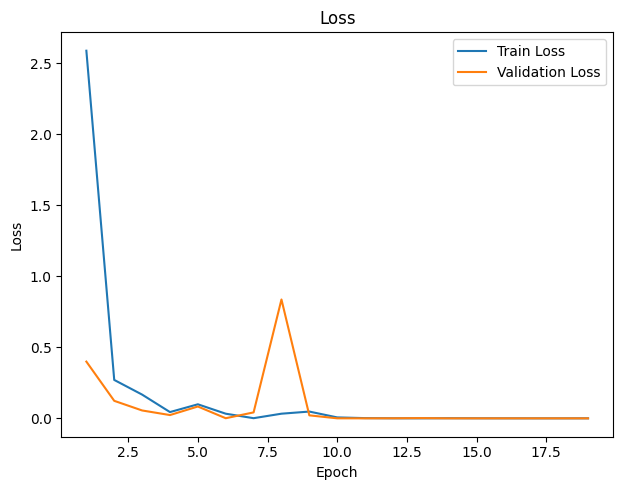

In [35]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_loss_scores) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_scores, label='Train Loss')
plt.plot(epochs, val_loss_scores, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# plt.subplot(1, 2, 2)
# plt.plot(epochs, val_accuracy_scores, label='Validation Accuracy', color='orange')
# plt.title('Validation Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()

plt.tight_layout()
plt.show()


In [36]:
train_loss, train_accuracy = evaluate(model, train_loader, criterion, device)
val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

modelResult = [train_accuracy, val_accuracy]
modelResult

#전체 모델 저장
torch.save(model,"../../keras/Data/ccn_face.pth")

#전체 모델 불러오기
model1=torch.load("../../keras/Data/ccn_face.pth",weights_only=False)

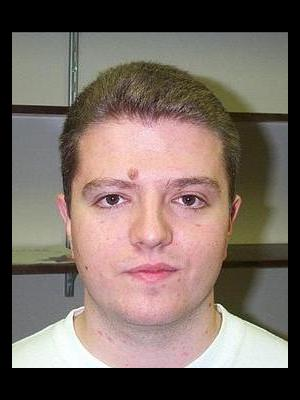

In [37]:
from PIL import Image
import numpy as np

# 첫 번째 얼굴 이미지 사용
abc=images[0].astype(np.uint8)
abc.shape

#Image 만들기
image=Image.fromarray(abc)
image

#image저장
image.save("../../keras/Data/face_00.png")

#image불러와서 예측
img=Image.open("../../keras/Data/face_00.png")
img


In [38]:
#image를 numpyarray
img=np.array(img)
img=torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
img.shape

img.shape

classes = ['Aiden', 'Andrew', 'Cathy']

def predictOne(model, image, device, classes):
    model.eval()
    with torch.no_grad():
        image = image.to(device)
        outputs = model(image.unsqueeze(0))
        _, predicted = torch.max(outputs, 1)
        predicted_classes = classes[predicted.item()]
    return predicted_classes

aiden_files = sorted(glob.glob("../../keras/Data/FaceColor/Aiden/*.jpg"))

img = np.array(Image.open(aiden_files[0]), dtype=np.int32)
img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0

predictOne(model, img, device, classes)

'Aiden'